# Chapter 12 - Training at Scale

This notebook keeps the examples small while introducing a few practical tools that matter once training runs get longer or datasets get larger. We will reuse one tiny synthetic classification task to look at throughput, safe mixed-precision code paths, gradient accumulation, checkpointing, and learning-rate schedules.

The focus is workflow, not benchmark chasing. A separate exercises notebook can extend these ideas once the main patterns are clear.

## Setup

We create one shared toy dataset and a small MLP so the later sections stay comparable and run quickly on either CPU or GPU.

In [1]:
# !pip -q install torch matplotlib  # install dependencies if needed

import random
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

plt.style.use("seaborn-v0_8")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def make_toy_split(n_train=2048, n_val=512, n_features=64, n_classes=4, seed=42):
    g = torch.Generator().manual_seed(seed)
    w1 = torch.randn(n_features, 96, generator=g)
    b1 = torch.randn(96, generator=g)
    w2 = torch.randn(96, n_classes, generator=g)
    b2 = torch.randn(n_classes, generator=g)

    def sample(n):
        x = torch.randn(n, n_features, generator=g)
        hidden = torch.relu(x @ w1 + b1)
        noise = 0.35 * torch.randn(n, n_classes, generator=g)
        logits = hidden @ w2 + b2 + noise
        y = logits.argmax(dim=1)
        return x.float(), y.long()

    return sample(n_train), sample(n_val)


(X_train, y_train), (X_val, y_val) = make_toy_split()
train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)


def make_loaders(batch_size=128, seed=42):
    train_generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=train_generator)
    val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
    return train_loader, val_loader


class TinyMLP(nn.Module):
    def __init__(self, in_features=64, hidden=128, num_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def make_model(hidden=128):
    return TinyMLP(hidden=hidden).to(device)


criterion = nn.CrossEntropyLoss()


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            total_loss += criterion(logits, yb).item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_examples += xb.size(0)

    return total_loss / total_examples, total_correct / total_examples


def train_one_epoch(model, loader, optimizer, *, accum_steps=1, amp_enabled=False, scaler=None):
    model.train()
    total_loss = 0.0
    total_examples = 0
    optimizer_steps = 0
    optimizer.zero_grad(set_to_none=True)

    for step, (xb, yb) in enumerate(loader, start=1):
        xb, yb = xb.to(device), yb.to(device)

        with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
            logits = model(xb)
            loss = criterion(logits, yb) / accum_steps

        if amp_enabled:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        if step % accum_steps == 0 or step == len(loader):
            if amp_enabled:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            optimizer_steps += 1

        total_loss += loss.item() * xb.size(0) * accum_steps
        total_examples += xb.size(0)

    return total_loss / total_examples, optimizer_steps


train_loader, val_loader = make_loaders(batch_size=128)
print(f"Training samples: {len(train_ds)}, validation samples: {len(val_ds)}")
print(f"Feature shape: {X_train.shape}, label shape: {y_train.shape}")

Using device: cpu
Training samples: 2048, validation samples: 512
Feature shape: torch.Size([2048, 64]), label shape: torch.Size([2048])


## Throughput quick check

This is a fast timing pass rather than a full benchmark. We keep the model fixed, vary the batch size, and measure how many examples per second a short training loop can process.

Batch size | Samples / second | Final loss
        32 |           255676 |     1.0051
       128 |           922765 |     1.3011
       512 |          2004600 |     1.3722


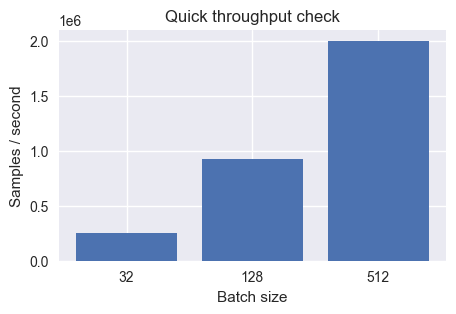

In [2]:
def measure_step_throughput(batch_size, steps=40):
    set_seed(42)
    model = make_model()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
    xb = torch.randn(batch_size, X_train.shape[1], device=device)
    yb = torch.randint(0, 4, (batch_size,), device=device)

    for _ in range(5):
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()

    for _ in range(steps):
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    return (batch_size * steps) / elapsed, loss.item()


throughput_results = []
for batch_size in [32, 128, 512]:
    samples_per_second, final_loss = measure_step_throughput(batch_size)
    throughput_results.append((batch_size, samples_per_second, final_loss))

print("Batch size | Samples / second | Final loss")
for batch_size, samples_per_second, final_loss in throughput_results:
    print(f"{batch_size:>10} | {samples_per_second:>16.0f} | {final_loss:>10.4f}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(
    [str(batch_size) for batch_size, _, _ in throughput_results],
    [samples_per_second for _, samples_per_second, _ in throughput_results],
    color="#4C72B0",
)
ax.set_xlabel("Batch size")
ax.set_ylabel("Samples / second")
ax.set_title("Quick throughput check")
plt.show()

## AMP training step

Automatic mixed precision can speed up training on supported GPUs. The same code path should still run safely on CPU-only setups by disabling autocast and gradient scaling.

In [3]:
amp_enabled = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

set_seed(42)
model = make_model()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
xb, yb = next(iter(train_loader))
xb, yb = xb.to(device), yb.to(device)

weight_before = model.net[0].weight.detach().clone()
optimizer.zero_grad(set_to_none=True)

with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
    logits = model(xb)
    loss = criterion(logits, yb)

scaler.scale(loss).backward()
grad_norm = model.net[0].weight.grad.detach().norm().item()
scaler.step(optimizer)
scaler.update()
weight_after = model.net[0].weight.detach().clone()

print(f"AMP enabled: {amp_enabled}")
print(f"Logits dtype inside autocast: {logits.dtype}")
print(f"Loss: {loss.item():.4f}")
print(f"Gradient norm: {grad_norm:.4f}")
print(f"Parameter change (L2 norm): {(weight_after - weight_before).norm().item():.6f}")
if not amp_enabled:
    print("CUDA is not available, so this step runs in standard precision with the same overall training-step structure.")

AMP enabled: False
Logits dtype inside autocast: torch.float32
Loss: 1.3509
Gradient norm: 0.1120
Parameter change (L2 norm): 0.905043
CUDA is not available, so this step runs in standard precision with the same overall training-step structure.


## Gradient accumulation

Gradient accumulation lets us combine several micro-batches before one optimizer update. That is useful when a full large batch would not fit comfortably in memory.

Accum steps | Effective batch | Optimizer steps/epoch | Final val acc
          1 |              64 |                   32 |        0.691
          4 |             256 |                    8 |        0.703


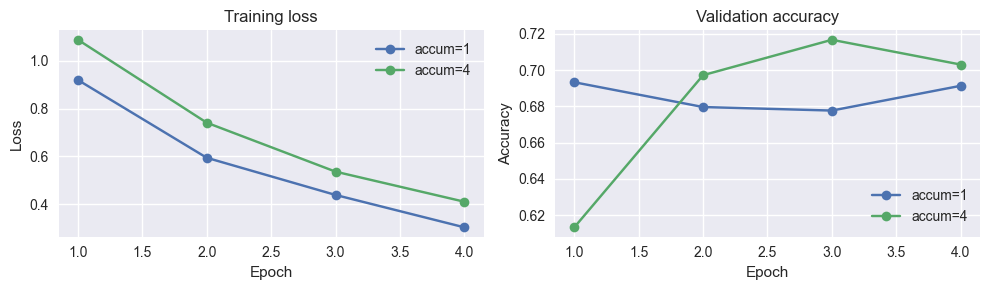

In [4]:
def run_accumulation_experiment(accum_steps, epochs=4, batch_size=64):
    set_seed(42)
    train_loader, val_loader = make_loaders(batch_size=batch_size, seed=42)
    model = make_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
    history = {"train_loss": [], "val_acc": [], "optimizer_steps": []}

    for _ in range(epochs):
        train_loss, optimizer_steps = train_one_epoch(
            model, train_loader, optimizer, accum_steps=accum_steps
        )
        _, val_acc = evaluate(model, val_loader)
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        history["optimizer_steps"].append(optimizer_steps)

    return history


accumulation_results = {
    1: run_accumulation_experiment(accum_steps=1),
    4: run_accumulation_experiment(accum_steps=4),
}

print("Accum steps | Effective batch | Optimizer steps/epoch | Final val acc")
for accum_steps, history in accumulation_results.items():
    effective_batch = 64 * accum_steps
    final_steps = history["optimizer_steps"][-1]
    final_acc = history["val_acc"][-1]
    print(f"{accum_steps:>11} | {effective_batch:>15} | {final_steps:>20} | {final_acc:>12.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
epochs = range(1, 5)
for accum_steps, history in accumulation_results.items():
    label = f"accum={accum_steps}"
    axes[0].plot(epochs, history["train_loss"], marker="o", label=label)
    axes[1].plot(epochs, history["val_acc"], marker="o", label=label)

axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[1].set_title("Validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

## Checkpoint save/load

A checkpoint should preserve enough state to resume or reproduce a run later. Here we save the model state, optimizer state, epoch number, and a small metric snapshot, then reload everything into a fresh model.

In [5]:
set_seed(42)
train_loader, val_loader = make_loaders(batch_size=128, seed=42)
model = make_model()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)

for _ in range(2):
    train_one_epoch(model, train_loader, optimizer)

val_loss_before, val_acc_before = evaluate(model, val_loader)
reference_batch = next(iter(val_loader))[0].to(device)
reference_logits = model(reference_batch).detach().cpu()

with tempfile.TemporaryDirectory() as tmpdir:
    checkpoint_path = Path(tmpdir) / "ch12_demo_checkpoint.pt"
    torch.save(
        {
            "epoch": 2,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_metrics": {"loss": val_loss_before, "acc": val_acc_before},
        },
        checkpoint_path,
    )

    restored_model = make_model()
    restored_optimizer = torch.optim.Adam(restored_model.parameters(), lr=5e-3)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    restored_model.load_state_dict(checkpoint["model_state"])
    restored_optimizer.load_state_dict(checkpoint["optimizer_state"])
    restored_logits = restored_model(reference_batch).detach().cpu()
    max_logit_diff = (reference_logits - restored_logits).abs().max().item()

print(f"Saved epoch: {checkpoint['epoch']}")
print(f"Validation loss before save: {val_loss_before:.4f}")
print(f"Validation accuracy before save: {val_acc_before:.3f}")
print(f"Reloaded validation metrics: {checkpoint['val_metrics']}")
print(f"Max logit difference after reload: {max_logit_diff:.6f}")

Saved epoch: 2
Validation loss before save: 0.7653
Validation accuracy before save: 0.695
Reloaded validation metrics: {'loss': 0.7652868032455444, 'acc': 0.6953125}
Max logit difference after reload: 0.000000


## Learning-rate schedules

A learning-rate schedule changes how aggressively the optimizer moves as training progresses. We compare a constant learning rate, a step schedule, and a cosine schedule on the same small task.

Schedule | Final lr | Final val acc
constant |  0.01000 |         0.709
    step |  0.00250 |         0.719
  cosine |  0.00067 |         0.719


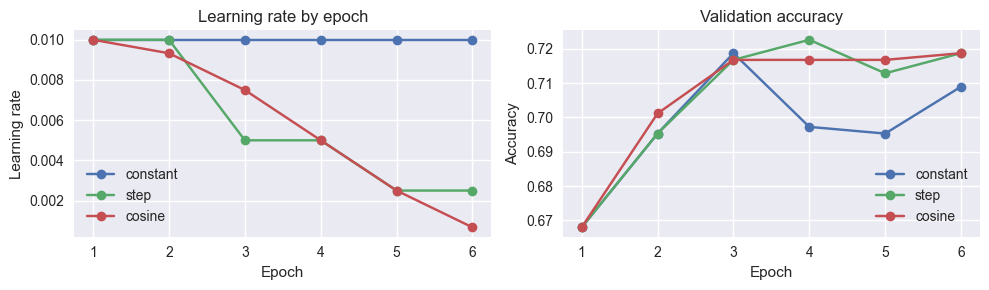

In [6]:
def build_scheduler(name, optimizer, epochs):
    if name == "constant":
        return None
    if name == "step":
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
    if name == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    raise ValueError(f"Unknown schedule: {name}")


def run_schedule_experiment(name, epochs=6):
    set_seed(42)
    train_loader, val_loader = make_loaders(batch_size=128, seed=42)
    model = make_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
    scheduler = build_scheduler(name, optimizer, epochs)
    history = {"lr": [], "val_loss": [], "val_acc": []}

    for _ in range(epochs):
        history["lr"].append(optimizer.param_groups[0]["lr"])
        train_one_epoch(model, train_loader, optimizer)
        val_loss, val_acc = evaluate(model, val_loader)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        if scheduler is not None:
            scheduler.step()

    return history


schedule_histories = {
    name: run_schedule_experiment(name)
    for name in ["constant", "step", "cosine"]
}

print("Schedule | Final lr | Final val acc")
for name, history in schedule_histories.items():
    print(f"{name:>8} | {history['lr'][-1]:>8.5f} | {history['val_acc'][-1]:>13.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
epochs = range(1, 7)
for name, history in schedule_histories.items():
    axes[0].plot(epochs, history["lr"], marker="o", label=name)
    axes[1].plot(epochs, history["val_acc"], marker="o", label=name)

axes[0].set_title("Learning rate by epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Learning rate")
axes[1].set_title("Validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

## Summary

This notebook kept Chapter 12 focused on a few practical training patterns:

- Throughput depends partly on batch size and hardware, so quick timing checks are useful before a long run.
- AMP can speed up training on supported GPUs, while the same code can safely fall back to standard precision on CPU.
- Gradient accumulation lets small micro-batches emulate a larger effective batch size.
- Checkpoints preserve model and optimizer state so a run can be resumed or reproduced.
- Learning-rate schedules change how aggressively the optimizer moves through training.

A separate exercises notebook can turn these ideas into guided comparisons once the core workflow feels comfortable.